### В этом блокноте проводится EDA для корпуса данных VoiceBio для построения основных зависимостей и распределений

Импорт библиотек

In [1]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns
import librosa
from pathlib import Path

Загрузка датасета

In [2]:
dataset_path = "/mnt/storage/work_dir/databases/voice_biometrics_age/voice_biometrics_age"

Распределение длительностей

Найдено 816 аудиофайлов


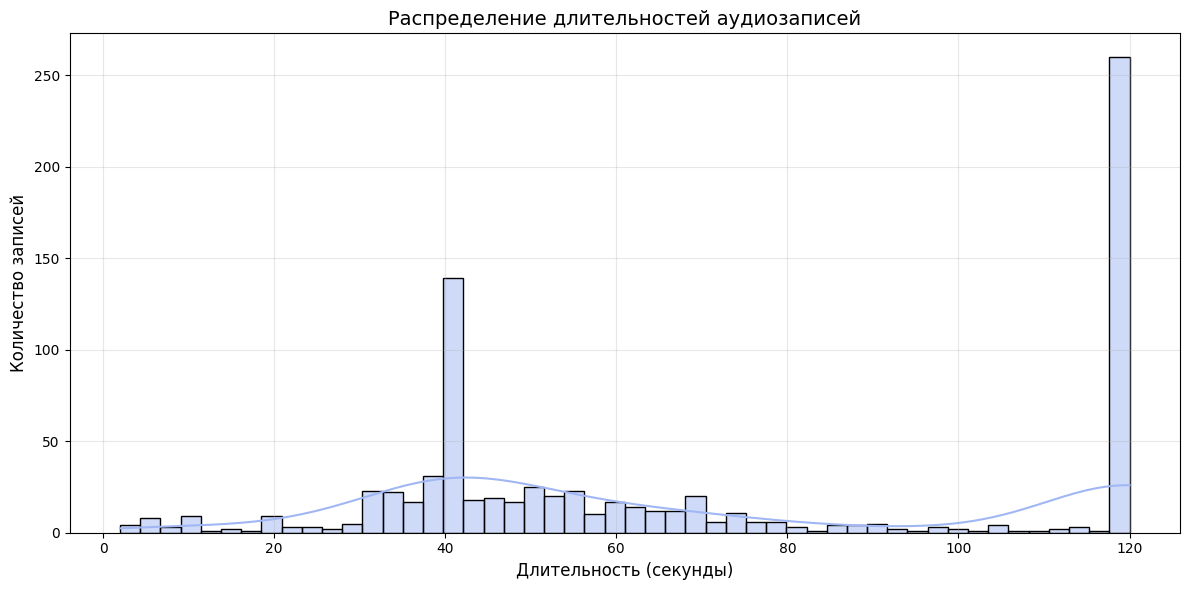

Минимум: 2.00 сек
Максимум: 120.00 сек
Среднее: 71.36 сек
Медиана: 57.43 сек


In [3]:
audio_files = []
for audio_path in Path(dataset_path).rglob('*.wav'):
    audio_files.append(str(audio_path))

print(f"Найдено {len(audio_files)} аудиофайлов")

durations = []
for audio_file in audio_files:
    try:
        duration = librosa.get_duration(path=audio_file)
        durations.append(duration)
    except:
        continue

plt.figure(figsize=(12, 6))
sns.histplot(durations, bins=50, kde=True, color='#A1B7F4')
plt.xlabel('Длительность (секунды)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Распределение длительностей аудиозаписей', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Минимум: {min(durations):.2f} сек")
print(f"Максимум: {max(durations):.2f} сек")
print(f"Среднее: {np.mean(durations):.2f} сек")
print(f"Медиана: {np.median(durations):.2f} сек")

In [4]:
df_persons = pd.read_excel("/mnt/storage/work_dir/databases/voice_biometrics_age/metadata.xlsx")

In [5]:
df_persons.head()

,id,original name,gender (male or female),date of birth,language,original links,dataset's author
0,id00001,Dmitry Vetrov,male,1981-08-17 00:00:00,russian,1. https://www.youtube.com/watch?v=tWYUW19pm3k...,Vladimir Volokhov
1,id00002,Dmitry Kuplinov,male,1988-11-25 00:00:00,russian,1. https://www.youtube.com/embed/gas1Md6H5E4 \...,Alexandr Kuzmin
2,id00003,Vladimir Putin,male,1952-10-07 00:00:00,russian,1. https://www.youtube.com/embed/N51wRdzVlJI \...,NaN
3,id00004,Boris Yeltsin,male,1931-02-01 00:00:00,russian,1. https://www.youtube.com/embed/Ec21ADatAXw \...,NaN
4,id00005,Petro Poroshenko,male,1965-09-26 00:00:00,ukrainian,1. https://www.youtube.com/embed/CfEhq-zpL2k \...,NaN


У некоторых нет даты рождения

In [6]:
df_persons[df_persons['date of birth']=='-'][['id', 'original name']]

,id,original name
82,id00083,Johnny B
83,id00084,Anna Studio
87,id00088,Natalia Shelkovskaya
89,id00090,\nMarina Dolganova


Пример человека без даты рождения

In [7]:
df_persons[df_persons['id']=='id00083']

,id,original name,gender (male or female),date of birth,language,original links,dataset's author
82,id00083,Johnny B,female,-,russian,https://www.youtube.com/@johnnydetka \n1. http...,NaN


Возраст можно получить для 147 людей.

Языки, встречающиеся в датасете

In [56]:
df_persons['language'].unique().tolist()

['russian', 'ukrainian', 'english', 'french', 'deutsch', 'spanish', 'korean']

In [8]:
df_persons['original links'].fillna('').astype(str).str.findall(r'https?://[^\s]+|www\.[^\s]+').str.len().value_counts().sort_index()

5     32
6    119
Name: original links, dtype: int64

In [8]:
text = df_persons[df_persons['id'] == 'id00009']['original links'].values[0]

if pd.notna(text):
    count = len(re.findall(r'\d+\.', str(text)))
    print(f"Количество ссылок для id00009: {count}")
else:
    print("Нет данных")

Количество ссылок для id00009: 5


Распределение по полу

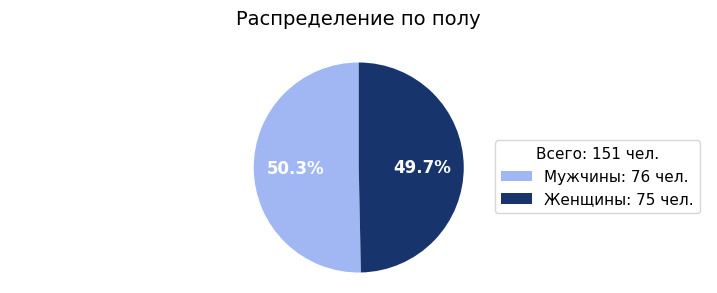

In [10]:
# Строим распределение по полу
gender_counts = df_persons['gender (male or female)'].value_counts()

plt.figure(figsize=(9, 3))

colors = ['#A1B7F4', "#17346D"]
wedges, texts, autotexts = plt.pie(gender_counts.values, 
                                    labels=None,
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 12, 'color': 'white', 'fontweight': 'bold'})

plt.legend(wedges, 
           [f'Мужчины: {gender_counts.get("male", 0)} чел.', 
            f'Женщины: {gender_counts.get("female", 0)} чел.'],
           loc='upper right',
           bbox_to_anchor=(1, 0.65),
           frameon=True,
           fontsize=11,
           title=f'Всего: {len(df_persons)} чел.',
           title_fontsize=11)

plt.title('Распределение по полу', loc='center', fontsize=14, pad=20)
plt.axis('equal')
plt.show()

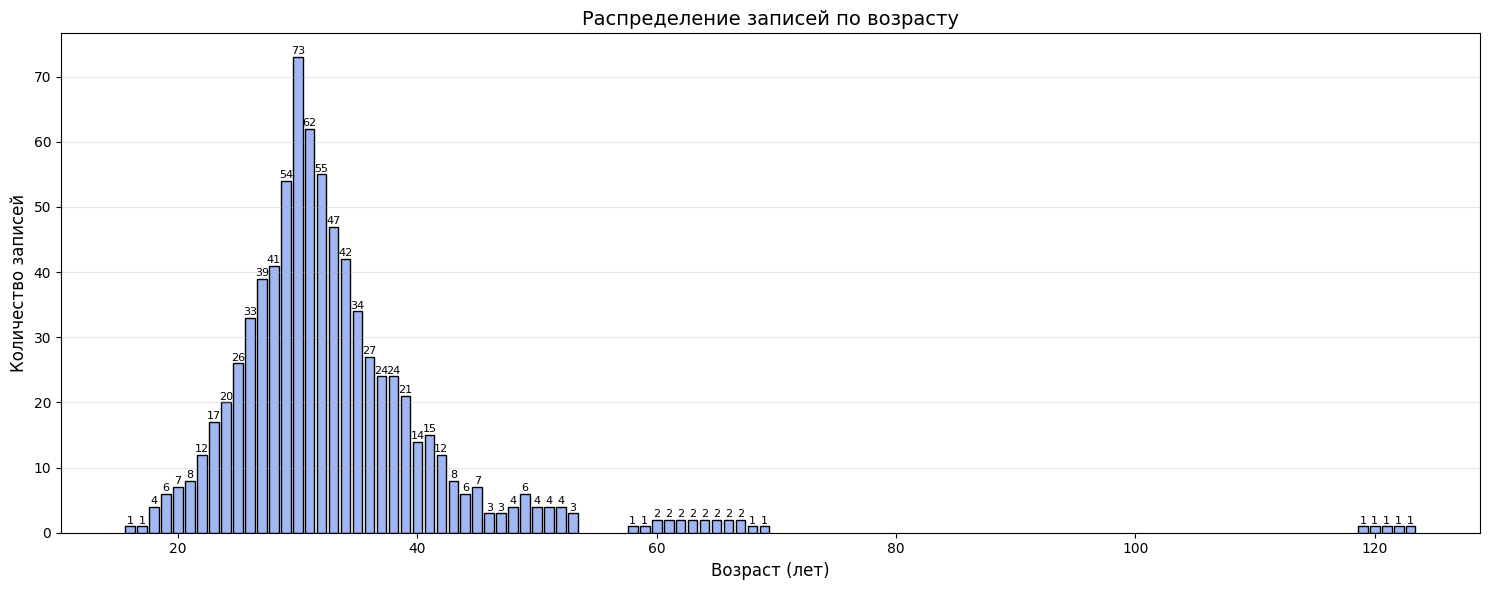


Статистика по возрасту:

Всего записей: 796
Всего говорящих: 147
Возрастной диапазон: 16-123 лет
Средний возраст: 33.4 лет
Медианный возраст: 31.0 лет
Стандартное отклонение: 10.7 лет


In [15]:
df_persons['date of birth'] = pd.to_datetime(df_persons['date of birth'], errors='coerce')
data = []

for person_dir in Path(dataset_path).iterdir():
    if not person_dir.is_dir():
        continue
    
    person_id = person_dir.name
    person_info = df_persons[df_persons['id'] == person_id]
    
    if person_info.empty or pd.isna(person_info['date of birth'].iloc[0]):
        continue
    
    birth_date = person_info['date of birth'].iloc[0]
    
    for year_dir in person_dir.iterdir():
        if not year_dir.is_dir():
            continue
        
        try:
            record_year = int(year_dir.name)
            age = record_year - birth_date.year
            
            wav_files = list(year_dir.glob('*.wav'))
            for audio_file in wav_files:
                data.append({
                    'id': person_id,
                    'year': record_year,
                    'age': age,
                    'file': str(audio_file)
                })
        except ValueError:
            continue

df_age = pd.DataFrame(data)

# Строим график распределения возрастов
plt.figure(figsize=(15, 6))

age_counts = df_age['age'].value_counts().sort_index()
plt.bar(age_counts.index, age_counts.values, color='#A1B7F4', edgecolor='black')
plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Распределение записей по возрасту', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for age, count in age_counts.items():
    plt.text(age, count + 0.1, str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Статистика
print(f"\nСтатистика по возрасту:\n")
print(f"Всего записей: {len(df_age)}")
print(f"Всего говорящих: {df_age['id'].nunique()}")
print(f"Возрастной диапазон: {df_age['age'].min()}-{df_age['age'].max()} лет")
print(f"Средний возраст: {df_age['age'].mean():.1f} лет")
print(f"Медианный возраст: {df_age['age'].median():.1f} лет")
print(f"Стандартное отклонение: {df_age['age'].std():.1f} лет")

## Для статьи

Найдено 816 аудиофайлов


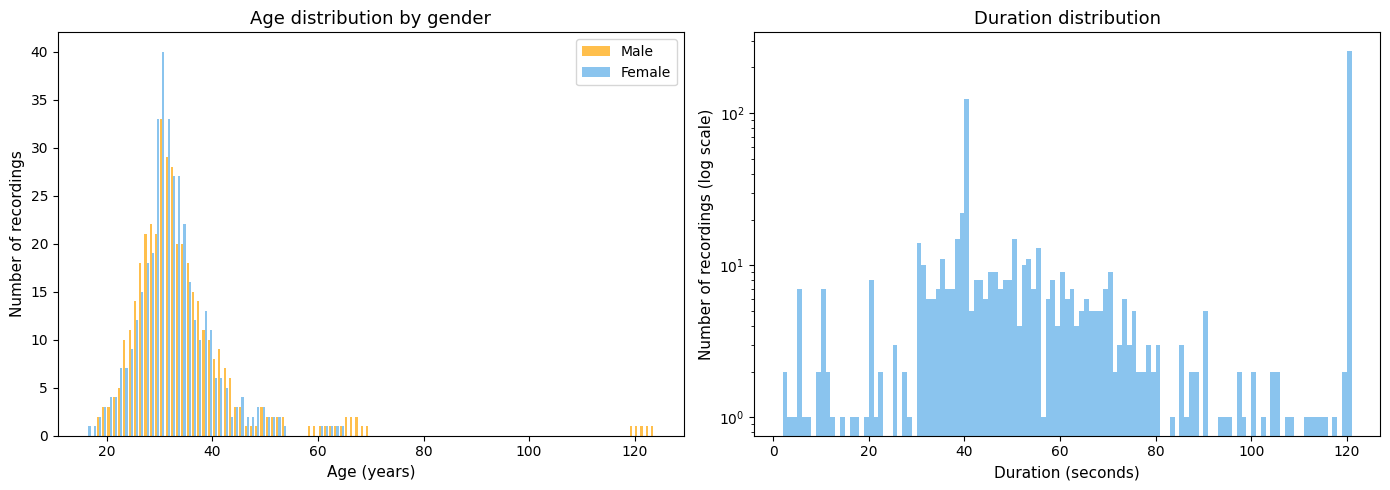

<Figure size 640x480 with 0 Axes>


СТАТИСТИКА ПО ВОЗРАСТУ:
Всего записей: 796
Всего говорящих: 147
Возрастной диапазон: 16-123 лет
Средний возраст: 33.4 лет
Медианный возраст: 31.0 лет

СТАТИСТИКА ПО ДЛИТЕЛЬНОСТЯМ:
Минимум: 2.00 сек
Максимум: 120.00 сек
Среднее: 71.36 сек
Медиана: 57.43 сек
Стандартное отклонение: 37.11 сек


In [ ]:
# Загружаем данные из Excel
df_persons = pd.read_excel("/mnt/storage/work_dir/databases/voice_biometrics_age/metadata.xlsx")

# Обрабатываем даты рождения, пропуски заменяем на NaT
df_persons['date of birth'] = pd.to_datetime(df_persons['date of birth'], errors='coerce')

# Собираем информацию о записях
data = []
dataset_path = '/mnt/storage/work_dir/databases/voice_biometrics_age/voice_biometrics_age'

for person_dir in Path(dataset_path).iterdir():
    if not person_dir.is_dir():
        continue
    
    person_id = person_dir.name
    person_info = df_persons[df_persons['id'] == person_id]
    
    if person_info.empty or pd.isna(person_info['date of birth'].iloc[0]):
        continue
    
    birth_date = person_info['date of birth'].iloc[0]
    gender = person_info['gender (male or female)'].iloc[0]
    
    for year_dir in person_dir.iterdir():
        if not year_dir.is_dir():
            continue
        
        try:
            record_year = int(year_dir.name)
            age = record_year - birth_date.year
            
            wav_files = list(year_dir.glob('*.wav'))
            for audio_file in wav_files:
                data.append({
                    'id': person_id,
                    'year': record_year,
                    'age': age,
                    'gender': gender,
                    'file': str(audio_file)
                })
        except ValueError:
            continue

df_age = pd.DataFrame(data)

# Собираем данные о длительностях
audio_files = []
for audio_path in Path(dataset_path).rglob('*.wav'):
    audio_files.append(str(audio_path))

print(f"Найдено {len(audio_files)} аудиофайлов")

durations = []
for audio_file in audio_files:
    try:
        duration = librosa.get_duration(path=audio_file)
        durations.append(duration)
    except:
        continue

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Распределение по возрасту с разделением по полу
male_ages = df_age[df_age['gender'] == 'male']['age']
female_ages = df_age[df_age['gender'] == 'female']['age']

bins = range(df_age['age'].min(), df_age['age'].max() + 2)

ax1.hist([male_ages, female_ages], 
         bins=bins,
         color=['orange', '#58ACE8'],
         label=['Male', 'Female'],
         edgecolor='none',
         alpha=0.7,
         stacked=False)

ax1.set_xlabel('Age (years)', fontsize=11)
ax1.set_ylabel('Number of recordings', fontsize=11)
ax1.set_title('Age distribution by gender', fontsize=13)
ax1.grid(False)
ax1.legend(fontsize=10)

# График 2: Распределение длительностей
sns.histplot(durations, bins=np.arange(2, 120 + 2), color='#58ACE8', edgecolor='none', alpha=0.7, log=True)
ax2.set_xlabel('Duration (seconds)', fontsize=11)
ax2.set_ylabel('Number of recordings (log scale)', fontsize=11)
ax2.set_title('Duration distribution', fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

# Подробная статистика
print(f"\n{'='*60}")
print(f"СТАТИСТИКА ПО ВОЗРАСТУ:")
print(f"{'='*60}")
print(f"Всего записей: {len(df_age)}")
print(f"Всего говорящих: {df_age['id'].nunique()}")
print(f"Возрастной диапазон: {df_age['age'].min()}-{df_age['age'].max()} лет")
print(f"Средний возраст: {df_age['age'].mean():.1f} лет")
print(f"Медианный возраст: {df_age['age'].median():.1f} лет")

print(f"\n{'='*60}")
print(f"СТАТИСТИКА ПО ДЛИТЕЛЬНОСТЯМ:")
print(f"{'='*60}")
print(f"Минимум: {min(durations):.2f} сек")
print(f"Максимум: {max(durations):.2f} сек")
print(f"Среднее: {np.mean(durations):.2f} сек")
print(f"Медиана: {np.median(durations):.2f} сек")
print(f"Стандартное отклонение: {np.std(durations):.2f} сек")

### Выводы
#### При проведении первичного анализа набора данных VoiceBiometricAge были выявлены следующие закономерности:
- Возрастной диапазон колеблется от 16 до 123 лет;
- Наблюдается недостаток данных среди лиц пожилого возраста, детские голоса в базе отсутствуют;
- набор сбалансирован по полу;
- При анализе распределения длительностей аудиозаписей выявлено, что средняя продолжительность составляет 71.36 секунды, а сами длительности колеблются от 2 с. до 2-х минут.